# Introduction

This Notebook implements self-attention from scratch in PyTorch.

# Scaled dot product attention

In [1]:
import torch
import torch.nn.functional as F
import math


def scaled_dot_product_attention(query, key, value, mask=None):
    """
    Computes scaled dot-product attention.
    
    Args:
    query: Tensor of shape (batch_size, seq_len, d_k)
    key: Tensor of shape (batch_size, seq_len, d_k)
    value: Tensor of shape (batch_size, seq_len, d_v)
    mask: Optional tensor used to hide certain positions
    
    Returns:
    output: Weighted sum of values
    attention_weights: Attention distribution over tokens
    """
    
    d_k = query.size(-1)
    
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))
    
    attention_weights = F.softmax(scores, dim=-1)
    
    output = torch.matmul(attention_weights, value)
    
    return output, attention_weights


To test this function, we can create a small batch of random embeddings.
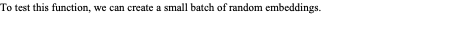
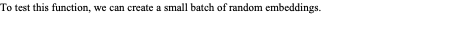
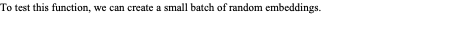
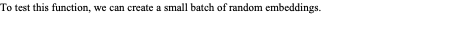

In [2]:
batch_size = 2
seq_len = 4
d_model = 8

x = torch.randn(batch_size, seq_len, d_model)

query = x
key = x
value = x

output, attention_weights = scaled_dot_product_attention(query, key, value)

print("Output shape:", output.shape)
print("Attention weights shape:", attention_weights.shape)


Output shape: torch.Size([2, 4, 8])
Attention weights shape: torch.Size([2, 4, 4])


# Adding learned queries, keys, and values projections

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


class SelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()

        self.d_model = d_model

        self.query = nn.Linear(d_model, d_model)
        self.key = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_model)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attention_weights = F.softmax(scores, dim=-1)

        output = torch.matmul(attention_weights, v)

        return output, attention_weights


To test it, we proceed as following:

In [4]:
attention = SelfAttention(d_model=8)

x = torch.randn(2, 4, 8)

output, weights = attention(x)

print(output.shape)
print(weights.shape)

torch.Size([2, 4, 8])
torch.Size([2, 4, 4])


# Causal masking for Decoder-only models
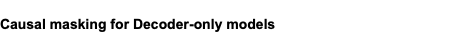
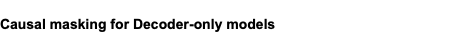
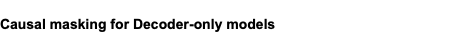
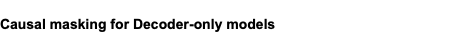

In [5]:
def causal_mask(seq_len):
    """
    Creates a lower-triangular causal mask.

    Shape: (1, seq_len, seq_len)
    """
    mask = torch.tril(torch.ones(seq_len, seq_len))
    return mask.unsqueeze(0)

Let's test it.

In [6]:
mask = causal_mask(5)
print(mask[0])

tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1.]])


The zeros represent positions that should be hidden. When we pass this mask into the attention layer, future tokens receive a score of negative infinity before softmax. After softmax, their attention weight becomes zero.

In [7]:
x = torch.randn(1, 5, 8)

attention = SelfAttention(d_model=8)

mask = causal_mask(seq_len=5)

output, weights = attention(x, mask=mask)

print(weights[0])

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5255, 0.4745, 0.0000, 0.0000, 0.0000],
        [0.4828, 0.2249, 0.2923, 0.0000, 0.0000],
        [0.2428, 0.2389, 0.2866, 0.2317, 0.0000],
        [0.1953, 0.2213, 0.2281, 0.1914, 0.1640]], grad_fn=<SelectBackward0>)


# From single-head to multi-head attention 

In [8]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        if d_model % num_heads != 0:
            raise ValueError("d_model must be divisible by num_heads")

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads

        self.query = nn.Linear(d_model, d_model)
        self.key = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)

        self.output_projection = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        batch_size, seq_len, _ = x.shape

        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        q = q.view(batch_size, seq_len, self.num_heads, self.d_head)
        k = k.view(batch_size, seq_len, self.num_heads, self.d_head)
        v = v.view(batch_size, seq_len, self.num_heads, self.d_head)

        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_head)

        if mask is not None:
            mask = mask.unsqueeze(1)
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attention_weights = F.softmax(scores, dim=-1)

        attention_output = torch.matmul(attention_weights, v)

        attention_output = attention_output.transpose(1, 2)
        attention_output = attention_output.contiguous().view(
            batch_size, seq_len, self.d_model
        )

        output = self.output_projection(attention_output)

        return output, attention_weights



The key operation here is reshaping the tensors. Initially, the query tensor has shape (`batch_seize`, `seq_len`, `d_model`). After reshaping and transposing, it becomes (`batch_size`, `num_heads`, `seq_len`, `d_head`). This allows PyTorch to compute attention for all heads in parallel. We can test this with the following module:
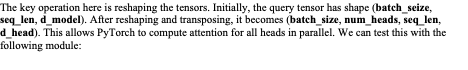
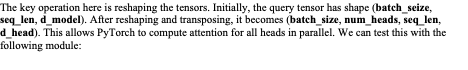
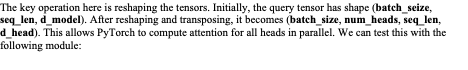
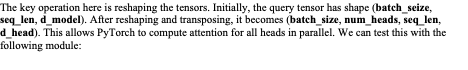

In [9]:
x = torch.randn(2, 6, 32)

multi_head_attention = MultiHeadSelfAttention(d_model=32, num_heads=4)

output, weights = multi_head_attention(x)

print("Output shape:", output.shape)
print("Attention weights shape:", weights.shape)


Output shape: torch.Size([2, 6, 32])
Attention weights shape: torch.Size([2, 4, 6, 6])


# Adding embeddings and positional information

In [10]:
class TokenAndPositionEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_seq_len):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_seq_len, d_model)

    def forward(self, token_ids):
        batch_size, seq_len = token_ids.shape

        positions = torch.arange(seq_len, device=token_ids.device)
        positions = positions.unsqueeze(0).expand(batch_size, seq_len)

        token_vectors = self.token_embedding(token_ids)
        position_vectors = self.position_embedding(positions)

        return token_vectors + position_vectors


This gives the model both the identity of each token and its position in the sequence.
Now we can combine multi-head self-attention with a feedforward layer, residual connections, and layer normalization. This gives us a simplified decoder-style Transformer block.
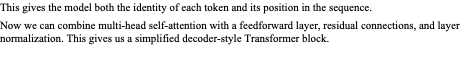
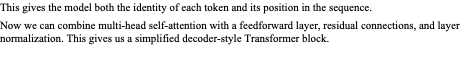
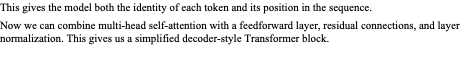
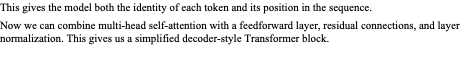

# A Minimal Decoder-Style Attention Block

Now we can combine multi-head self-attention with a feedforward layer, residual connections, and layer normalization. This gives us a simplified decoder-style Transformer block.

In [11]:
class TransformerDecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        self.attention = MultiHeadSelfAttention(d_model, num_heads)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attention_output, attention_weights = self.attention(x, mask=mask)

        x = self.norm1(x + self.dropout(attention_output))

        ff_output = self.feed_forward(x)

        x = self.norm2(x + self.dropout(ff_output))

        return x, attention_weights


This block now contains the main ingredients of a decoder-only Transformer layer. The masked self-attention layer allows tokens to attend only to previous tokens. The feedforward network transforms each token representation independently. The residual connections help gradients flow through the network, and layer normalization stabilizes training.

# A tiny Decoder-only language model

In [12]:
class TinyDecoderOnlyTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=64,
        num_heads=4,
        d_ff=256,
        num_layers=2,
        max_seq_len=128,
        dropout=0.1,
    ):
        super().__init__()

        self.embedding = TokenAndPositionEmbedding(
            vocab_size=vocab_size,
            d_model=d_model,
            max_seq_len=max_seq_len,
        )

        self.blocks = nn.ModuleList([
            TransformerDecoderBlock(
                d_model=d_model,
                num_heads=num_heads,
                d_ff=d_ff,
                dropout=dropout,
            )
            for _ in range(num_layers)
        ])

        self.output_layer = nn.Linear(d_model, vocab_size)

    def forward(self, token_ids):
        batch_size, seq_len = token_ids.shape

        x = self.embedding(token_ids)

        mask = causal_mask(seq_len).to(token_ids.device)

        attention_maps = []

        for block in self.blocks:
            x, attention_weights = block(x, mask=mask)
            attention_maps.append(attention_weights)

        logits = self.output_layer(x)

        return logits, attention_maps

Let's test it here.

In [13]:
vocab_size = 1000

model = TinyDecoderOnlyTransformer(
    vocab_size=vocab_size,
    d_model=64,
    num_heads=4,
    d_ff=256,
    num_layers=2,
    max_seq_len=32,
)

token_ids = torch.randint(0, vocab_size, (2, 16))

logits, attention_maps = model(token_ids)

print("Logits shape:", logits.shape)
print("Attention map from first layer:", attention_maps[0].shape)


Logits shape: torch.Size([2, 16, 1000])
Attention map from first layer: torch.Size([2, 4, 16, 16])


# Training objective for next token prediction

For a decoder-only language model, training usually follows a next-token prediction setup.  

Given a sequence:  
```I love machine learning```  
the model receives:   
```I love machine```  
and learnd to predict:  
```love machine learning```  
In token form, we shift the input and target sequences by one proposition.
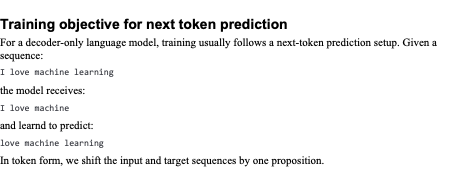
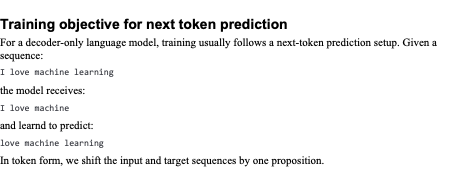
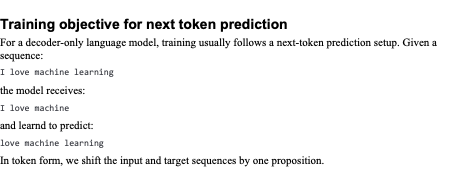
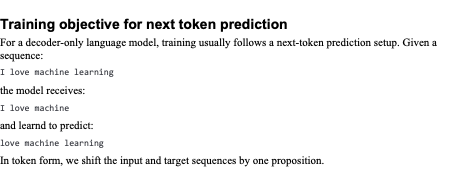

In [14]:
criterion = nn.CrossEntropyLoss()

batch_size = 4
seq_len = 10
vocab_size = 1000

token_ids = torch.randint(0, vocab_size, (batch_size, seq_len))

inputs = token_ids[:, :-1]
targets = token_ids[:, 1:]

logits, _ = model(inputs)

loss = criterion(
    logits.reshape(-1, vocab_size),
    targets.reshape(-1)
)

print("Loss:", loss.item())


Loss: 7.096928119659424


# A minimal trainin step

In [15]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
model.train()
optimizer.zero_grad()
logits, _ = model(inputs)
loss = criterion(
    logits.reshape(-1, vocab_size),
    targets.reshape(-1)
)
loss.backward()
optimizer.step()
print("Training loss:", loss.item())


Training loss: 7.086287498474121
